## 1️⃣ Import Libraries và Cấu hình

In [51]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import joblib
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Cấu hình
DATA_PATH = '../data_file/'
OUTPUT_DIR = './output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Các mốc thời gian dự đoán (giờ)
HORIZONS = [1, 2, 4, 6, 12, 24]

print("✅ Libraries imported successfully")
print(f"📂 Output directory: {OUTPUT_DIR}")
print(f"⏱️  Forecast horizons: {HORIZONS}")

✅ Libraries imported successfully
📂 Output directory: ./output
⏱️  Forecast horizons: [1, 2, 4, 6, 12, 24]


In [52]:
# Cài đặt LightGBM và CatBoost
!pip install lightgbm catboost


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 2️⃣ Load và Merge Dữ liệu

Tích hợp 4 nguồn dữ liệu:
- **Air Quality**: PM2.5, PM10, O3, SO2, NO2, CO
- **Weather**: Nhiệt độ, độ ẩm, gió, áp suất, v.v.
- **Holidays**: Ngày lễ, Tết
- **Traffic Proxy**: Chỉ số tắc nghẽn giao thông

In [53]:
# Load dữ liệu
air = pd.read_csv(f'{DATA_PATH}hanoi_air_quality_history.csv')
weather = pd.read_csv(f'{DATA_PATH}hanoi_weather_history.csv')
holidays = pd.read_csv(f'{DATA_PATH}hanoi_holidays_aligned.csv')
traffic = pd.read_csv(f'{DATA_PATH}hanoi_traffic_proxy.csv')

print("📂 Loading data files...")
print(f"   ✓ Air Quality: {air.shape}")
print(f"   ✓ Weather: {weather.shape}")
print(f"   ✓ Holidays: {holidays.shape}")
print(f"   ✓ Traffic: {traffic.shape}")

# Chuyển đổi datetime
air['datetime'] = pd.to_datetime(air['datetime'], format='%Y-%m-%d:%H')
weather['datetime'] = pd.to_datetime(weather['datetime'], format='%Y-%m-%d:%H')
holidays['datetime'] = pd.to_datetime(holidays['datetime'])
traffic['datetime'] = pd.to_datetime(traffic['datetime'])  # Auto detect format

# Chuẩn hóa holidays columns
if 'holiday_name' not in holidays.columns:
    holidays['holiday_name'] = ''
if 'is_holiday' not in holidays.columns:
    holidays['is_holiday'] = (holidays['holiday_name'].notna() & (holidays['holiday_name'] != '')).astype(int)

holidays = holidays[['datetime', 'is_holiday', 'holiday_name']]

# Merge datasets
print("\n🔗 Merging datasets...")
df = pd.merge(air, weather, on='datetime', how='inner')
df = pd.merge(df, holidays, on='datetime', how='left')

# Merge traffic - select only needed columns
traffic_cols = ['datetime', 'congestion_index']
if 'congestion_noise' in traffic.columns:
    traffic_cols.append('congestion_noise')

df = pd.merge(df, traffic[traffic_cols], on='datetime', how='left')

# Fill missing holiday values
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)
df['holiday_name'] = df['holiday_name'].fillna('')

# Fill missing congestion_noise if it exists
if 'congestion_noise' in df.columns:
    df['congestion_noise'] = df['congestion_noise'].fillna(0)

df = df.sort_values('datetime').reset_index(drop=True)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📅 Time range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"📈 Total records: {len(df):,}")

# Hiển thị mẫu dữ liệu
df.head()

📂 Loading data files...
   ✓ Air Quality: (25429, 8)
   ✓ Weather: (25393, 12)
   ✓ Holidays: (24024, 3)
   ✓ Traffic: (24816, 4)

🔗 Merging datasets...

📊 Dataset shape: (25392, 23)
📅 Time range: 2022-12-31 17:00:00 → 2025-12-28 16:00:00
📈 Total records: 25,392


,datetime,aqi,pm25,pm10,o3,so2,no2,co,temp,app_temp,...,pres,vis,clouds,precip,uv,dewpt,is_holiday,holiday_name,congestion_index,congestion_noise
0,2022-12-31 17:00:00,155,59.0,73.8,55.7,62.3,9.0,224.5,14.8,14.8,...,1024.0,10.0,87,0.0,0.0,10.0,0,,91.0,-1.76
1,2022-12-31 18:00:00,171,71.0,88.8,56.0,59.0,6.0,206.0,14.6,14.6,...,1023.0,10.0,87,0.0,0.0,10.2,0,,94.0,-3.43
2,2022-12-31 19:00:00,179,77.0,96.3,54.0,58.0,6.0,203.7,14.3,14.3,...,1023.0,10.0,83,0.0,0.0,10.7,0,,82.0,-2.11
3,2022-12-31 20:00:00,199,92.0,115.0,52.0,57.0,6.0,201.3,14.1,14.1,...,1023.0,10.0,79,0.0,0.0,11.0,0,,40.0,-0.18
4,2022-12-31 21:00:00,161,64.0,80.0,50.0,56.0,6.0,199.0,13.8,13.8,...,1022.0,10.0,75,0.0,0.0,11.5,0,,61.0,-1.52


## 🧪 Preprocessing analysis (external)

Báo cáo chi tiết được sinh từ script:
- `data/analysis/preprocessing/generate_preprocess_report.py`
- Output: `data/analysis/preprocessing/preprocess_report.md`

Chạy tại root project:
```bash
python3 data/analysis/preprocessing/generate_preprocess_report.py
```


In [54]:
print("="*80)
print("📊 THỐNG KÊ DỮ LIỆU TỔNG QUAN")
print("="*80)

# Kiểm tra missing values
print("\n1. MISSING VALUES:")
print("-"*80)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Percentage': missing_pct[missing > 0]
}).sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("   ✅ Không có giá trị thiếu!")

# Thống kê các biến số
print("\n2. THỐNG KÊ CÁC BIẾN SỐ:")
print("-"*80)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Số biến số: {len(numeric_cols)}")
print(f"   Các biến: {', '.join(numeric_cols[:10])}...")

# Thống kê ngày lễ
print("\n3. THỐNG KÊ NGÀY LỄ:")
print("-"*80)
holiday_count = df['is_holiday'].sum()
print(f"   Tổng số giờ trong ngày lễ: {holiday_count} ({holiday_count/len(df)*100:.1f}%)")
print(f"   Tổng số giờ thường: {len(df) - holiday_count} ({(len(df)-holiday_count)/len(df)*100:.1f}%)")

unique_holidays = df[df['is_holiday'] == 1]['holiday_name'].value_counts()
if len(unique_holidays) > 0:
    print(f"\n   Các ngày lễ trong dataset:")
    for holiday, count in unique_holidays.head(10).items():
        if holiday:
            print(f"      • {holiday}: {count} giờ")

# Thống kê traffic
print("\n4. THỐNG KÊ GIAO THÔNG:")
print("-"*80)
print(f"   Congestion Index - Mean: {df['congestion_index'].mean():.1f}")
print(f"   Congestion Index - Min: {df['congestion_index'].min():.1f}")
print(f"   Congestion Index - Max: {df['congestion_index'].max():.1f}")
print(f"   Congestion Index - Std: {df['congestion_index'].std():.1f}")

if 'congestion_noise' in df.columns:
    print(f"\n   Congestion Noise - Mean: {df['congestion_noise'].mean():.2f}")
    print(f"   Congestion Noise - Std: {df['congestion_noise'].std():.2f}")

📊 THỐNG KÊ DỮ LIỆU TỔNG QUAN

1. MISSING VALUES:
--------------------------------------------------------------------------------
                  Missing Count  Percentage
congestion_index           1368        5.39
vis                           7        0.03

2. THỐNG KÊ CÁC BIẾN SỐ:
--------------------------------------------------------------------------------
   Số biến số: 21
   Các biến: aqi, pm25, pm10, o3, so2, no2, co, temp, app_temp, rh...

3. THỐNG KÊ NGÀY LỄ:
--------------------------------------------------------------------------------
   Tổng số giờ trong ngày lễ: 717 (2.8%)
   Tổng số giờ thường: 24675 (97.2%)

   Các ngày lễ trong dataset:
      • Tết Nguyên Đán: 480 giờ
      • Tết Dương Lịch: 72 giờ
      • Ngày Quốc Tế Lao Động: 72 giờ
      • Quốc Khánh: 72 giờ
      • Ngày Giải Phóng: 21 giờ

4. THỐNG KÊ GIAO THÔNG:
--------------------------------------------------------------------------------
   Congestion Index - Mean: 60.4
   Congestion Index - Min: 10.0


## 2️⃣.1 Thống kê Dữ liệu Tổng quan

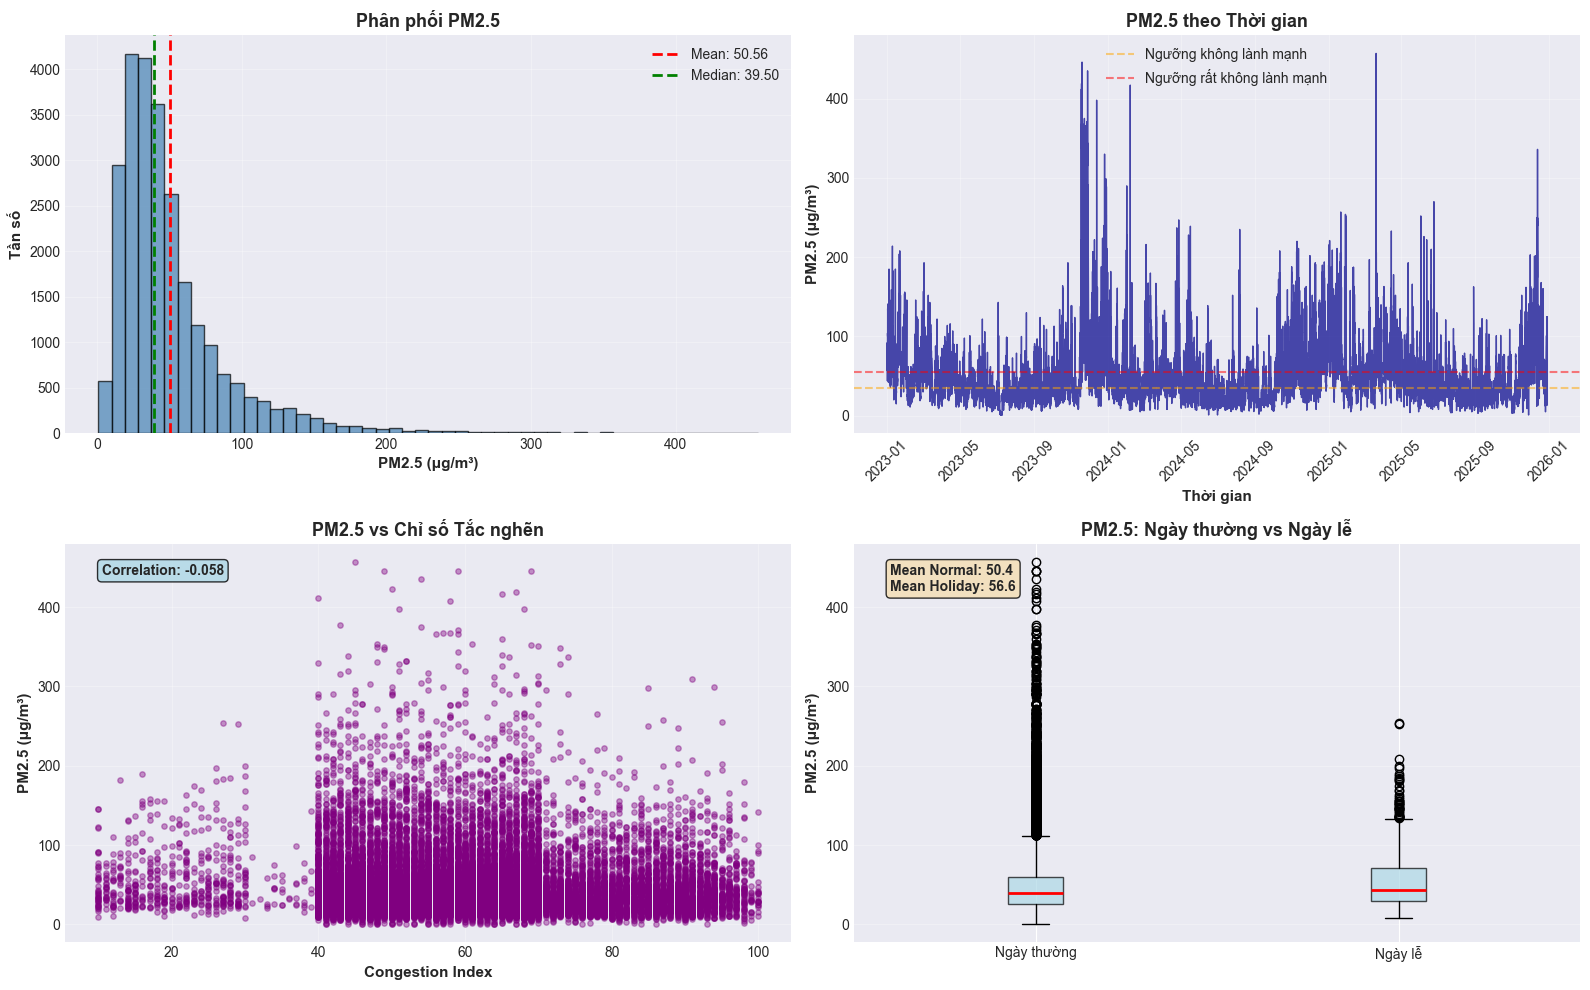


📊 PHÂN TÍCH PM2.5:
   Mean: 50.56 μg/m³
   Median: 39.50 μg/m³
   Std: 40.59 μg/m³
   Min: 1.00 μg/m³
   Max: 457.00 μg/m³
   Skewness: 2.76
   Kurtosis: 12.27


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Phân phối PM2.5
axes[0, 0].hist(df['pm25'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['pm25'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df["pm25"].mean():.2f}')
axes[0, 0].axvline(df['pm25'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {df["pm25"].median():.2f}')
axes[0, 0].set_xlabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Tần số', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Phân phối PM2.5', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Time series PM2.5
axes[0, 1].plot(df['datetime'], df['pm25'], linewidth=1, alpha=0.7, color='darkblue')
axes[0, 1].axhline(y=35.5, color='orange', linestyle='--', alpha=0.5, 
                   label='Ngưỡng không lành mạnh')
axes[0, 1].axhline(y=55.5, color='red', linestyle='--', alpha=0.5, 
                   label='Ngưỡng rất không lành mạnh')
axes[0, 1].set_xlabel('Thời gian', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('PM2.5 theo Thời gian', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. PM2.5 vs Traffic
axes[1, 0].scatter(df['congestion_index'], df['pm25'], alpha=0.4, s=15, color='purple')
axes[1, 0].set_xlabel('Congestion Index', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('PM2.5 vs Chỉ số Tắc nghẽn', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Correlation
corr_traffic = df[['congestion_index', 'pm25']].corr().iloc[0, 1]
axes[1, 0].text(0.05, 0.95, f'Correlation: {corr_traffic:.3f}',
               transform=axes[1, 0].transAxes,
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
               verticalalignment='top', fontweight='bold')

# 4. PM2.5: Holiday vs Non-holiday
holiday_data = [df[df['is_holiday']==0]['pm25'].dropna(), 
                df[df['is_holiday']==1]['pm25'].dropna()]
axes[1, 1].boxplot(holiday_data, labels=['Ngày thường', 'Ngày lễ'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('PM2.5: Ngày thường vs Ngày lễ', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Stats
mean_normal = df[df['is_holiday']==0]['pm25'].mean()
mean_holiday = df[df['is_holiday']==1]['pm25'].mean()
axes[1, 1].text(0.05, 0.95, 
               f'Mean Normal: {mean_normal:.1f}\nMean Holiday: {mean_holiday:.1f}',
               transform=axes[1, 1].transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               verticalalignment='top', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pm25_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 PHÂN TÍCH PM2.5:")
print(f"   Mean: {df['pm25'].mean():.2f} μg/m³")
print(f"   Median: {df['pm25'].median():.2f} μg/m³")
print(f"   Std: {df['pm25'].std():.2f} μg/m³")
print(f"   Min: {df['pm25'].min():.2f} μg/m³")
print(f"   Max: {df['pm25'].max():.2f} μg/m³")
print(f"   Skewness: {df['pm25'].skew():.2f}")
print(f"   Kurtosis: {df['pm25'].kurtosis():.2f}")

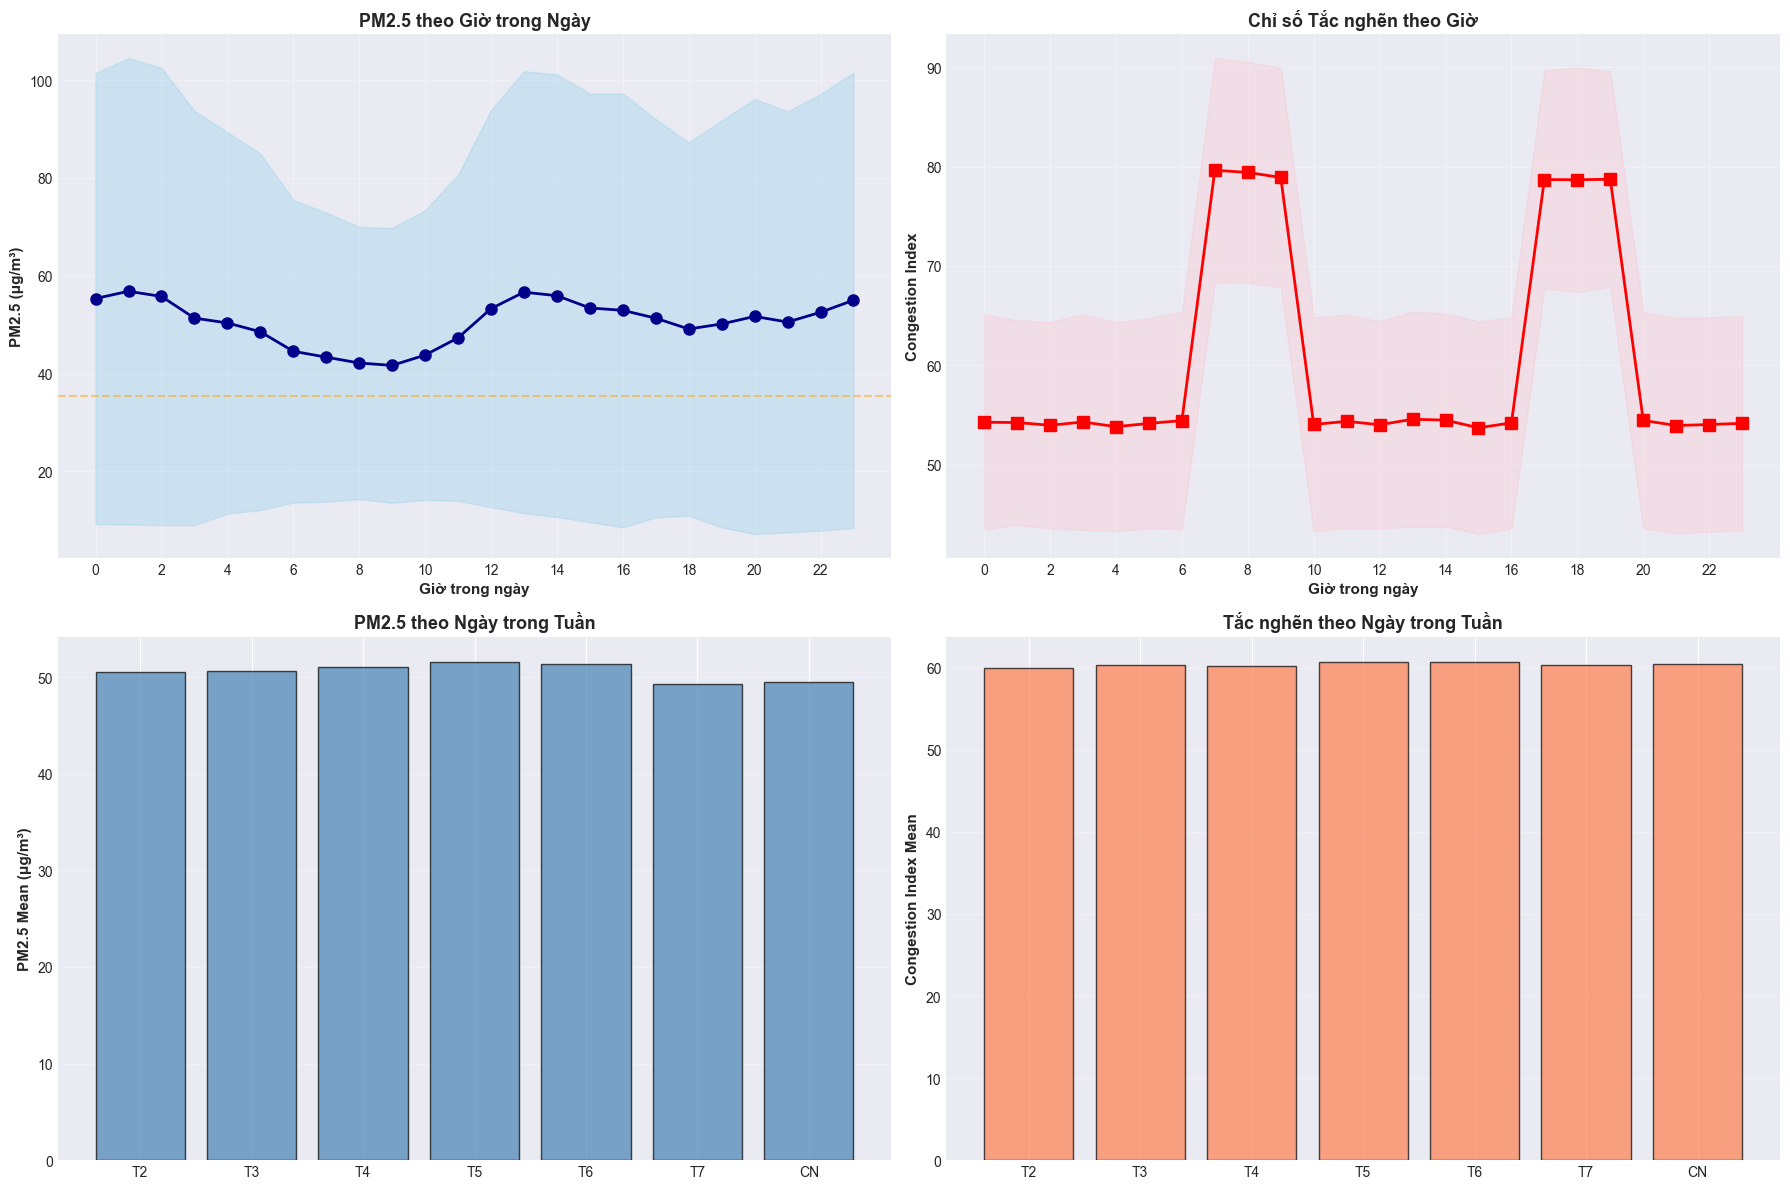


📊 XU HƯỚNG THEO THỜI GIAN:
   Giờ PM2.5 cao nhất: 1:00 (56.8 μg/m³)
   Giờ PM2.5 thấp nhất: 9:00 (41.7 μg/m³)

   Giờ tắc nghẽn cao nhất: 7:00 (79.6)


In [56]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. PM2.5 by hour
hourly_pm25 = df.groupby('hour')['pm25'].agg(['mean', 'std'])
axes[0, 0].plot(hourly_pm25.index, hourly_pm25['mean'], 
               marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0, 0].fill_between(hourly_pm25.index,
                       hourly_pm25['mean'] - hourly_pm25['std'],
                       hourly_pm25['mean'] + hourly_pm25['std'],
                       alpha=0.3, color='skyblue')
axes[0, 0].axhline(y=35.5, color='orange', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('PM2.5 theo Giờ trong Ngày', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# 2. Traffic by hour
hourly_traffic = df.groupby('hour')['congestion_index'].agg(['mean', 'std'])
axes[0, 1].plot(hourly_traffic.index, hourly_traffic['mean'],
               marker='s', linewidth=2, markersize=8, color='red')
axes[0, 1].fill_between(hourly_traffic.index,
                       hourly_traffic['mean'] - hourly_traffic['std'],
                       hourly_traffic['mean'] + hourly_traffic['std'],
                       alpha=0.3, color='pink')
axes[0, 1].set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Congestion Index', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Chỉ số Tắc nghẽn theo Giờ', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. PM2.5 by day of week
day_names = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
weekly_pm25 = df.groupby('day_of_week')['pm25'].mean()
axes[1, 0].bar(range(7), weekly_pm25.values, 
              color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names)
axes[1, 0].set_ylabel('PM2.5 Mean (μg/m³)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('PM2.5 theo Ngày trong Tuần', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Traffic by day of week
weekly_traffic = df.groupby('day_of_week')['congestion_index'].mean()
axes[1, 1].bar(range(7), weekly_traffic.values,
              color='coral', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(day_names)
axes[1, 1].set_ylabel('Congestion Index Mean', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Tắc nghẽn theo Ngày trong Tuần', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 XU HƯỚNG THEO THỜI GIAN:")
print("="*60)
peak_hour = hourly_pm25['mean'].idxmax()
lowest_hour = hourly_pm25['mean'].idxmin()
print(f"   Giờ PM2.5 cao nhất: {peak_hour}:00 ({hourly_pm25.loc[peak_hour, 'mean']:.1f} μg/m³)")
print(f"   Giờ PM2.5 thấp nhất: {lowest_hour}:00 ({hourly_pm25.loc[lowest_hour, 'mean']:.1f} μg/m³)")

peak_traffic_hour = hourly_traffic['mean'].idxmax()
print(f"\n   Giờ tắc nghẽn cao nhất: {peak_traffic_hour}:00 ({hourly_traffic.loc[peak_traffic_hour, 'mean']:.1f})")

## 2️⃣.4 Phân tích Xu hướng theo Thời gian và Giao thông

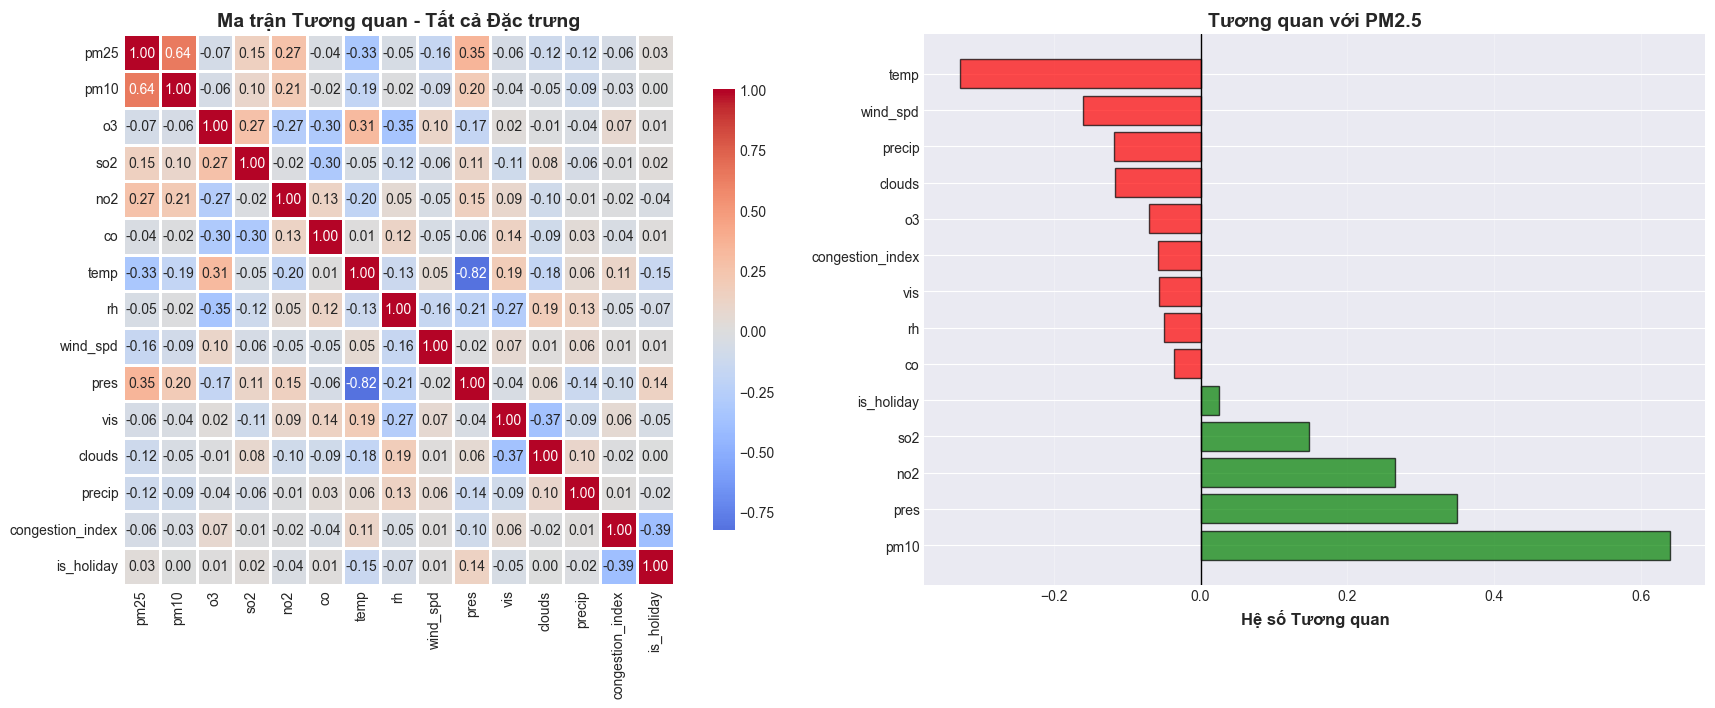


📊 TƯƠNG QUAN VỚI PM2.5 (Top 10):
   pm10                : +0.6398  [MẠNH]
   pres                : +0.3501  [TRUNG BÌNH]
   no2                 : +0.2651  [YẾU]
   so2                 : +0.1478  [YẾU]
   is_holiday          : +0.0256  [YẾU]
   co                  : -0.0356  [YẾU]
   rh                  : -0.0495  [YẾU]
   vis                 : -0.0570  [YẾU]
   congestion_index    : -0.0580  [YẾU]
   o3                  : -0.0699  [YẾU]


In [57]:
# Chọn các biến số quan trọng để phân tích
analysis_cols = ['pm25', 'pm10', 'o3', 'so2', 'no2', 'co', 
                 'temp', 'rh', 'wind_spd', 'pres', 'vis', 'clouds', 'precip',
                 'congestion_index', 'is_holiday']

corr_matrix = df[analysis_cols].corr()

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           ax=axes[0])
axes[0].set_title('Ma trận Tương quan - Tất cả Đặc trưng', 
                 fontsize=14, fontweight='bold')

# PM2.5 correlation bar chart
pm25_corr = corr_matrix['pm25'].sort_values(ascending=False)
pm25_corr = pm25_corr[pm25_corr.index != 'pm25']

colors = ['green' if x > 0 else 'red' for x in pm25_corr.values]
axes[1].barh(pm25_corr.index, pm25_corr.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Hệ số Tương quan', fontsize=12, fontweight='bold')
axes[1].set_title('Tương quan với PM2.5', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 TƯƠNG QUAN VỚI PM2.5 (Top 10):")
print("="*60)
for var, corr_val in pm25_corr.head(10).items():
    strength = "MẠNH" if abs(corr_val) > 0.5 else "TRUNG BÌNH" if abs(corr_val) > 0.3 else "YẾU"
    print(f"   {var:20s}: {corr_val:+.4f}  [{strength}]")

## 2️⃣.3 Phân tích Tương quan

## 2️⃣.2 Phân tích Đặc trưng PM2.5 (Target Variable)

## 2️⃣.1 Thống kê Dữ liệu Tổng quan

In [58]:
print("="*80)
print("📊 THỐNG KÊ DỮ LIỆU TỔNG QUAN")
print("="*80)

# Kiểm tra missing values
print("\n1. MISSING VALUES:")
print("-"*80)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Percentage': missing_pct[missing > 0]
}).sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("   ✅ Không có giá trị thiếu!")

# Thống kê các biến số
print("\n2. THỐNG KÊ CÁC BIẾN SỐ:")
print("-"*80)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Số biến số: {len(numeric_cols)}")
print(f"   Các biến: {', '.join(numeric_cols[:10])}...")

# Thống kê ngày lễ
print("\n3. THỐNG KÊ NGÀY LỄ:")
print("-"*80)
holiday_count = df['is_holiday'].sum()
print(f"   Tổng số giờ trong ngày lễ: {holiday_count} ({holiday_count/len(df)*100:.1f}%)")
print(f"   Tổng số giờ thường: {len(df) - holiday_count} ({(len(df)-holiday_count)/len(df)*100:.1f}%)")

unique_holidays = df[df['is_holiday'] == 1]['holiday_name'].value_counts()
if len(unique_holidays) > 0:
    print(f"\n   Các ngày lễ trong dataset:")
    for holiday, count in unique_holidays.head(10).items():
        if holiday:
            print(f"      • {holiday}: {count} giờ")

# Thống kê traffic
print("\n4. THỐNG KÊ GIAO THÔNG:")
print("-"*80)
print(f"   Congestion Index - Mean: {df['congestion_index'].mean():.1f}")
print(f"   Congestion Index - Min: {df['congestion_index'].min():.1f}")
print(f"   Congestion Index - Max: {df['congestion_index'].max():.1f}")
print(f"   Congestion Index - Std: {df['congestion_index'].std():.1f}")

📊 THỐNG KÊ DỮ LIỆU TỔNG QUAN

1. MISSING VALUES:
--------------------------------------------------------------------------------
                  Missing Count  Percentage
congestion_index           1368        5.39
vis                           7        0.03

2. THỐNG KÊ CÁC BIẾN SỐ:
--------------------------------------------------------------------------------
   Số biến số: 23
   Các biến: aqi, pm25, pm10, o3, so2, no2, co, temp, app_temp, rh...

3. THỐNG KÊ NGÀY LỄ:
--------------------------------------------------------------------------------
   Tổng số giờ trong ngày lễ: 717 (2.8%)
   Tổng số giờ thường: 24675 (97.2%)

   Các ngày lễ trong dataset:
      • Tết Nguyên Đán: 480 giờ
      • Tết Dương Lịch: 72 giờ
      • Ngày Quốc Tế Lao Động: 72 giờ
      • Quốc Khánh: 72 giờ
      • Ngày Giải Phóng: 21 giờ

4. THỐNG KÊ GIAO THÔNG:
--------------------------------------------------------------------------------
   Congestion Index - Mean: 60.4
   Congestion Index - Min: 10.0


## 3️⃣ Feature Engineering

Tạo các đặc trưng quan trọng cho mô hình:
- **Time features**: hour, day_of_week, month (cyclical encoding)
- **Lag features**: giá trị PM2.5, temp, wind_spd, traffic từ quá khứ
- **Rolling statistics**: mean, std, min, max trong cửa sổ thời gian
- **Difference features**: xu hướng thay đổi
- **Categorical features**: peak hour, night time, weekend, holiday
- **Interaction features**: tương tác giữa các biến
- **Traffic features**: congestion patterns và tương tác

In [59]:
def engineer_features(df):
    """Tạo các đặc trưng kỹ thuật cho mô hình"""
    df = df.copy()
    
    print("⚙️  Creating time features...")
    # Đặc trưng thời gian cơ bản
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    
    # Mã hóa tuần hoàn
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Xử lý hướng gió
    if 'wind_dir' in df.columns:
        df['wind_dir'] = df['wind_dir'] % 360
        df['wind_dir_rad'] = np.deg2rad(df['wind_dir'])
        df['wind_dir_sin'] = np.sin(df['wind_dir_rad'])
        df['wind_dir_cos'] = np.cos(df['wind_dir_rad'])
        df.drop(columns=['wind_dir', 'wind_dir_rad'], inplace=True)
    
    print("⚙️  Creating lag features...")
    # Lag features
    lags = [1, 3, 6, 12, 24, 48, 72]
    for lag in lags:
        df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)
        df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
        df[f'wind_spd_lag_{lag}'] = df['wind_spd'].shift(lag)
    
    print("⚙️  Creating rolling statistics...")
    # Rolling statistics
    windows = [6, 12, 24, 48]
    for win in windows:
        df[f'pm25_roll_mean_{win}'] = df['pm25'].rolling(win).mean()
        df[f'pm25_roll_std_{win}'] = df['pm25'].rolling(win).std()
        df[f'pm25_roll_min_{win}'] = df['pm25'].rolling(win).min()
        df[f'pm25_roll_max_{win}'] = df['pm25'].rolling(win).max()
    
    print("⚙️  Creating difference features...")
    # Difference features
    df['pm25_diff_1h'] = df['pm25'].diff(1)
    df['pm25_diff_24h'] = df['pm25'].diff(24)
    df['temp_diff_1h'] = df['temp'].diff(1)
    
    print("⚙️  Creating categorical features...")
    # Categorical features
    df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)
    df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 6 else 0)
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    print("⚙️  Creating interaction features...")
    # Interaction features
    df['temp_x_rh'] = df['temp'] * df['rh']
    df['wind_spd_x_temp'] = df['wind_spd'] * df['temp']
    
    # Remove NaN
    df = df.dropna().reset_index(drop=True)
    
    return df

# Apply feature engineering
df_feat = engineer_features(df)

print(f"\n✅ Feature engineering completed!")
print(f"📊 New dataset shape: {df_feat.shape}")
print(f"🔢 Total features: {df_feat.shape[1]}")
print(f"📈 Valid records: {len(df_feat):,}")

⚙️  Creating time features...
⚙️  Creating lag features...
⚙️  Creating rolling statistics...
⚙️  Creating difference features...
⚙️  Creating categorical features...
⚙️  Creating interaction features...

✅ Feature engineering completed!
📊 New dataset shape: (23945, 77)
🔢 Total features: 77
📈 Valid records: 23,945


## 4️⃣ Train Models for Each Horizon

Huấn luyện mô hình XGBoost riêng biệt cho mỗi mốc thời gian dự đoán.

In [60]:
def train_horizon_model(df_feat, horizon, model_type='xgboost'):
    """
    Huấn luyện mô hình cho một horizon cụ thể
    
    Args:
        df_feat: DataFrame với features
        horizon: Số giờ dự đoán
        model_type: 'xgboost', 'lightgbm', hoặc 'catboost'
    
    Returns:
        model: Trained model
        metrics: Performance metrics
        predictions: Test predictions DataFrame
        features: List of feature names
    """
    # Tạo target
    df_h = df_feat.copy()
    df_h['target'] = df_h['pm25'].shift(-horizon)
    df_h = df_h.dropna().reset_index(drop=True)
    
    # Prepare features
    exclude_cols = ['datetime', 'pm25', 'target', 'holiday_name']
    features = [c for c in df_h.columns if c not in exclude_cols]
    
    X = df_h[features]
    y = df_h['target']
    
    # Split data (80-20, no shuffle)
    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    
    # Train model based on type
    if model_type == 'xgboost':
        model = xgb.XGBRegressor(
            n_estimators=300,  # Giảm từ 500
            learning_rate=0.1,  # Tăng từ 0.05
            max_depth=6,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=20
        )
        model.fit(X_train, y_train, 
                 eval_set=[(X_test, y_test)], 
                 verbose=False)
        
    elif model_type == 'lightgbm':
        import lightgbm as lgb
        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(X_train, y_train,
                 eval_set=[(X_test, y_test)],
                 callbacks=[lgb.early_stopping(20, verbose=False)])
        
    elif model_type == 'catboost':
        from catboost import CatBoostRegressor
        model = CatBoostRegressor(
            iterations=300,
            learning_rate=0.1,
            depth=6,
            random_seed=42,
            thread_count=-1,
            verbose=False
        )
        model.fit(X_train, y_train,
                 eval_set=(X_test, y_test),
                 early_stopping_rounds=20,
                 verbose=False)
    
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Metrics
    metrics = {
        'model': model_type,
        'horizon': horizon,
        'train_r2': r2_score(y_train, train_preds),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_preds)),
        'train_mae': mean_absolute_error(y_train, train_preds),
        'test_r2': r2_score(y_test, test_preds),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_preds)),
        'test_mae': mean_absolute_error(y_test, test_preds),
        'n_features': len(features),
        'n_train': len(X_train),
        'n_test': len(X_test)
    }
    
    # Predictions DataFrame
    predictions = pd.DataFrame({
        'datetime': df_h.iloc[split_idx:]['datetime'].values,
        'actual': y_test.values,
        'predicted': test_preds,
        'error': y_test.values - test_preds,
        'abs_error': np.abs(y_test.values - test_preds),
        'model': model_type,
        'horizon': horizon
    })
    
    return model, metrics, predictions, features

print("🚀 Starting multi-model training...\n")
print("=" * 80)
print("Training 3 models: XGBoost, LightGBM, CatBoost")
print("=" * 80)

# Train all models
MODEL_TYPES = ['xgboost', 'lightgbm', 'catboost']
all_models = {model_type: {} for model_type in MODEL_TYPES}
all_metrics = []
all_predictions = []

for model_type in MODEL_TYPES:
    print(f"\n{'='*80}")
    print(f"🔧 TRAINING {model_type.upper()} MODELS")
    print(f"{'='*80}\n")
    
    for horizon in HORIZONS:
        print(f"⏱️  {model_type.capitalize()}: {horizon}h forecast...", end=' ')
        
        model, metrics, predictions, features = train_horizon_model(
            df_feat, horizon, model_type
        )
        
        all_models[model_type][horizon] = model
        all_metrics.append(metrics)
        all_predictions.append(predictions)
        
        # Save model
        model_path = f'{OUTPUT_DIR}/{model_type}_model_{horizon}h.pkl'
        joblib.dump(model, model_path)
        
        print(f"R²={metrics['test_r2']:.4f} | RMSE={metrics['test_rmse']:.2f} | MAE={metrics['test_mae']:.2f}")

print("\n" + "=" * 80)
print("✅ All models trained successfully!")
print("=" * 80)

# Save results
metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True)

metrics_df.to_csv(f'{OUTPUT_DIR}/all_models_results.csv', index=False)
predictions_df.to_csv(f'{OUTPUT_DIR}/all_predictions.csv', index=False)

print(f"\n💾 Results saved to {OUTPUT_DIR}/")
print(f"   📊 Total models trained: {len(MODEL_TYPES) * len(HORIZONS)}")
print(f"   📁 Files: all_models_results.csv, all_predictions.csv")

🚀 Starting multi-model training...

Training 3 models: XGBoost, LightGBM, CatBoost

🔧 TRAINING XGBOOST MODELS

⏱️  Xgboost: 1h forecast... R²=0.5914 | RMSE=15.36 | MAE=8.23
⏱️  Xgboost: 2h forecast... R²=0.4750 | RMSE=17.41 | MAE=9.76
⏱️  Xgboost: 4h forecast... R²=0.3553 | RMSE=19.29 | MAE=11.69
⏱️  Xgboost: 6h forecast... R²=0.2918 | RMSE=20.21 | MAE=12.64
⏱️  Xgboost: 12h forecast... R²=0.1918 | RMSE=21.57 | MAE=13.93
⏱️  Xgboost: 24h forecast... R²=0.1283 | RMSE=22.37 | MAE=14.93

🔧 TRAINING LIGHTGBM MODELS

⏱️  Lightgbm: 1h forecast... R²=0.5921 | RMSE=15.34 | MAE=8.21
⏱️  Lightgbm: 2h forecast... R²=0.4768 | RMSE=17.38 | MAE=9.66
⏱️  Lightgbm: 4h forecast... R²=0.3583 | RMSE=19.25 | MAE=11.56
⏱️  Lightgbm: 6h forecast... R²=0.2836 | RMSE=20.32 | MAE=12.68
⏱️  Lightgbm: 12h forecast... R²=0.1962 | RMSE=21.51 | MAE=13.76
⏱️  Lightgbm: 24h forecast... R²=0.1187 | RMSE=22.49 | MAE=14.86

🔧 TRAINING CATBOOST MODELS

⏱️  Catboost: 1h forecast... R²=0.5890 | RMSE=15.40 | MAE=8.21
⏱️  Ca

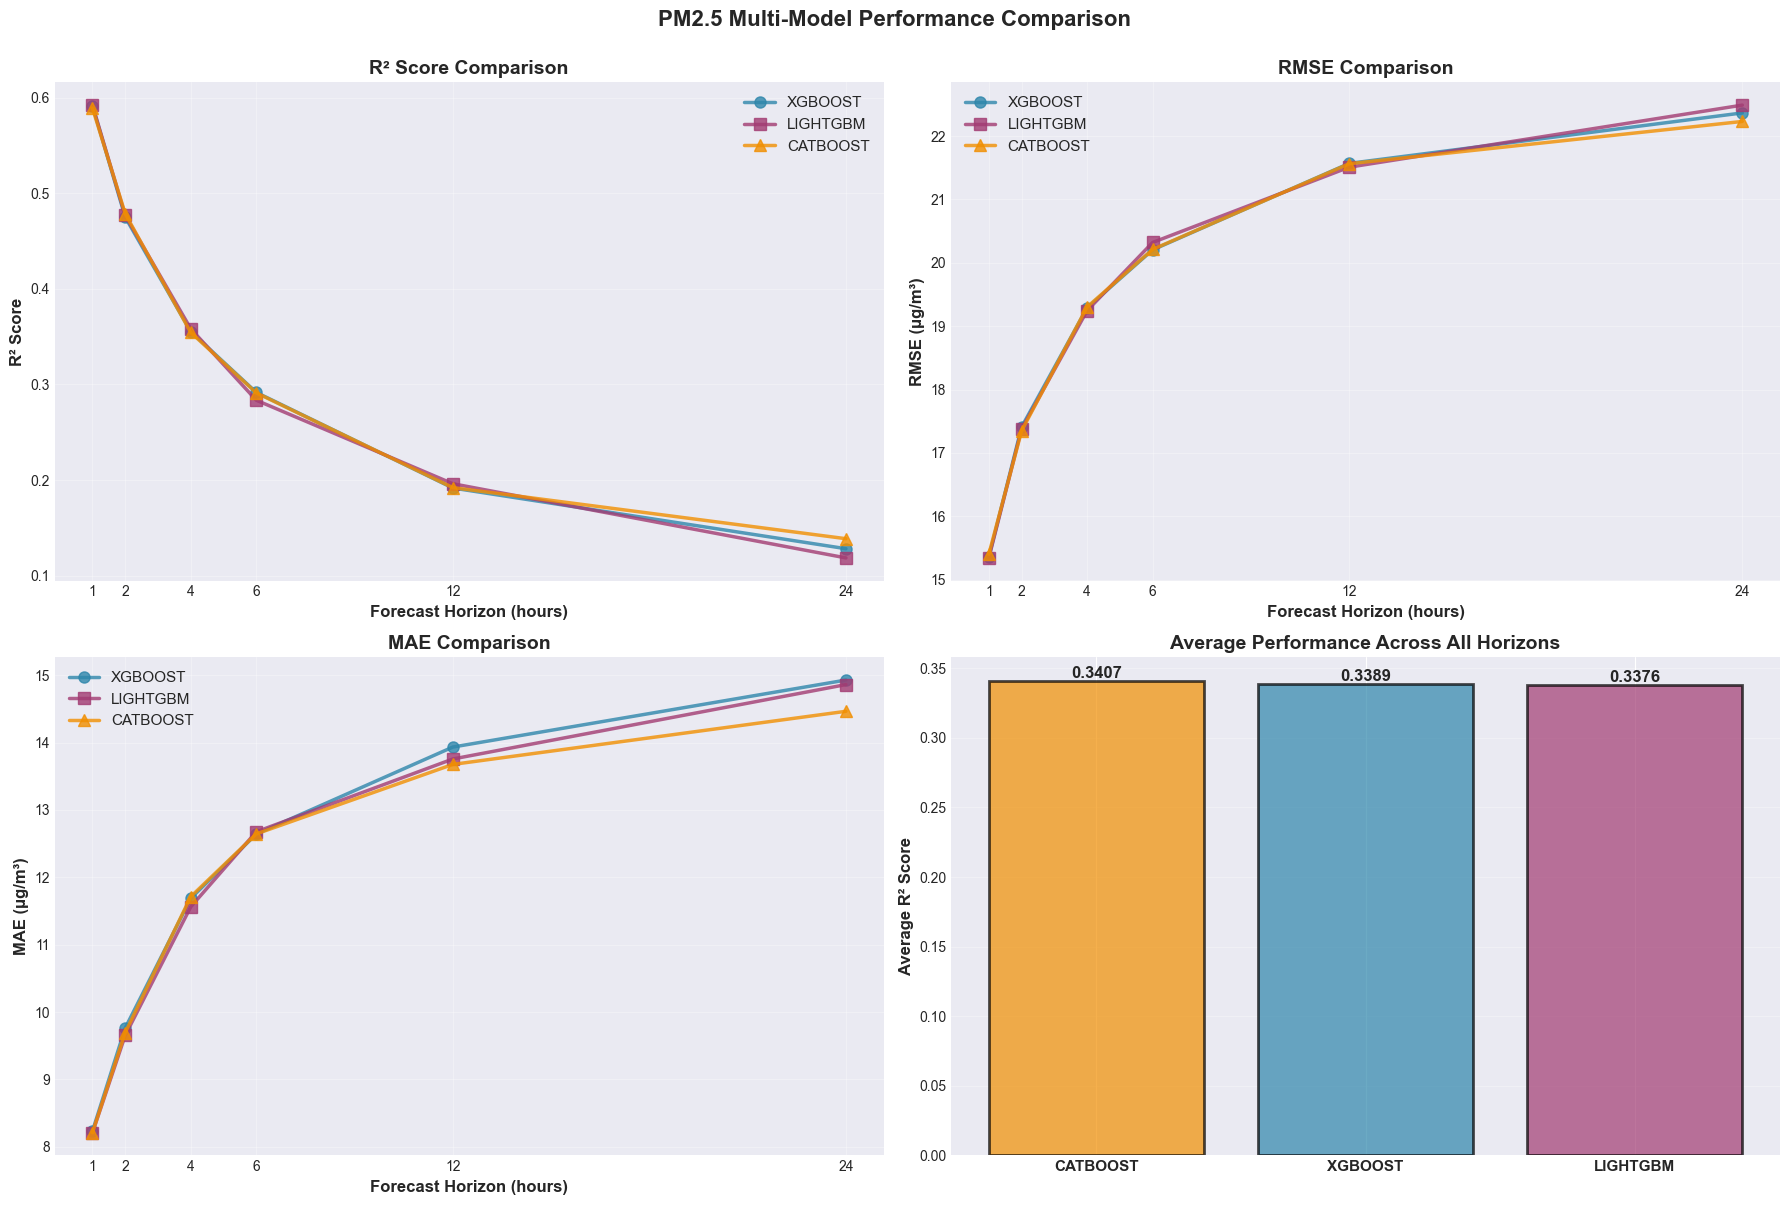

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Colors for each model
colors = {'xgboost': '#2E86AB', 'lightgbm': '#A23B72', 'catboost': '#F18F01'}
markers = {'xgboost': 'o', 'lightgbm': 's', 'catboost': '^'}

# 1. R² Score Comparison
for model in MODEL_TYPES:
    model_data = metrics_df[metrics_df['model'] == model].sort_values('horizon')
    axes[0, 0].plot(model_data['horizon'], model_data['test_r2'],
                   marker=markers[model], linewidth=2.5, markersize=8,
                   color=colors[model], label=model.upper(), alpha=0.8)

axes[0, 0].set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(HORIZONS)

# 2. RMSE Comparison
for model in MODEL_TYPES:
    model_data = metrics_df[metrics_df['model'] == model].sort_values('horizon')
    axes[0, 1].plot(model_data['horizon'], model_data['test_rmse'],
                   marker=markers[model], linewidth=2.5, markersize=8,
                   color=colors[model], label=model.upper(), alpha=0.8)

axes[0, 1].set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('RMSE (μg/m³)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(HORIZONS)

# 3. MAE Comparison
for model in MODEL_TYPES:
    model_data = metrics_df[metrics_df['model'] == model].sort_values('horizon')
    axes[1, 0].plot(model_data['horizon'], model_data['test_mae'],
                   marker=markers[model], linewidth=2.5, markersize=8,
                   color=colors[model], label=model.upper(), alpha=0.8)

axes[1, 0].set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAE (μg/m³)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('MAE Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(HORIZONS)

# 4. Average Performance Bar Chart
avg_perf = metrics_df.groupby('model')['test_r2'].mean().sort_values(ascending=False)
bars = axes[1, 1].bar(range(len(MODEL_TYPES)), 
                     [avg_perf[m] for m in avg_perf.index],
                     color=[colors[m] for m in avg_perf.index],
                     alpha=0.7, edgecolor='black', linewidth=2)

axes[1, 1].set_xticks(range(len(MODEL_TYPES)))
axes[1, 1].set_xticklabels([m.upper() for m in avg_perf.index], fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average R² Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Performance Across All Horizons', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, avg_perf.values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}', ha='center', va='bottom', 
                   fontweight='bold', fontsize=12)

plt.suptitle('PM2.5 Multi-Model Performance Comparison', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6️⃣ Visualization - Model Comparison

In [62]:
# So sánh performance của 3 models
print("="*80)
print("📊 MODEL COMPARISON - PERFORMANCE OVERVIEW")
print("="*80)

# Pivot table for easy comparison
comparison = metrics_df.pivot_table(
    index='horizon',
    columns='model',
    values=['test_r2', 'test_rmse', 'test_mae']
)

print("\n1️⃣ R² Score Comparison:")
print("-"*80)
r2_comparison = comparison['test_r2'].round(4)
print(r2_comparison)

print("\n2️⃣ RMSE Comparison:")
print("-"*80)
rmse_comparison = comparison['test_rmse'].round(2)
print(rmse_comparison)

print("\n3️⃣ MAE Comparison:")
print("-"*80)
mae_comparison = comparison['test_mae'].round(2)
print(mae_comparison)

# Find best model for each horizon
print("\n" + "="*80)
print("🏆 BEST MODEL FOR EACH HORIZON")
print("="*80)
for horizon in HORIZONS:
    horizon_data = metrics_df[metrics_df['horizon'] == horizon].sort_values('test_r2', ascending=False)
    best = horizon_data.iloc[0]
    print(f"{horizon:2d}h: {best['model'].upper():12s} - R²={best['test_r2']:.4f}, RMSE={best['test_rmse']:.2f}")

# Overall best model (average across all horizons)
print("\n" + "="*80)
print("🎯 OVERALL BEST MODEL (Average Performance)")
print("="*80)
avg_performance = metrics_df.groupby('model')[['test_r2', 'test_rmse', 'test_mae']].mean()
avg_performance = avg_performance.sort_values('test_r2', ascending=False)
print(avg_performance.round(4))

📊 MODEL COMPARISON - PERFORMANCE OVERVIEW

1️⃣ R² Score Comparison:
--------------------------------------------------------------------------------
model    catboost  lightgbm  xgboost
horizon                             
1          0.5890    0.5921   0.5914
2          0.4786    0.4768   0.4750
4          0.3544    0.3583   0.3553
6          0.2913    0.2836   0.2918
12         0.1922    0.1962   0.1918
24         0.1388    0.1187   0.1283

2️⃣ RMSE Comparison:
--------------------------------------------------------------------------------
model    catboost  lightgbm  xgboost
horizon                             
1           15.40     15.34    15.36
2           17.35     17.38    17.41
4           19.30     19.25    19.29
6           20.21     20.32    20.21
12          21.56     21.51    21.57
24          22.23     22.49    22.37

3️⃣ MAE Comparison:
--------------------------------------------------------------------------------
model    catboost  lightgbm  xgboost
horizon          

## 5️⃣ Model Comparison - XGBoost vs LightGBM vs CatBoost

## 5️⃣ Performance Summary

Tổng hợp và so sánh hiệu suất của các mô hình

In [63]:
# Display metrics table
print("📊 MODEL PERFORMANCE SUMMARY")
print("=" * 80)

summary = metrics_df[['horizon', 'test_r2', 'test_rmse', 'test_mae']].copy()
summary.columns = ['Horizon (h)', 'R²', 'RMSE (μg/m³)', 'MAE (μg/m³)']
summary = summary.round(4)

display(summary)

# Best performers
print("\n🏆 Best Performing Models:")
print("-" * 80)
sorted_by_r2 = metrics_df.sort_values('test_r2', ascending=False)
for i, row in sorted_by_r2.head(3).iterrows():
    print(f"{row['horizon']:2.0f}h: R²={row['test_r2']:.4f}, RMSE={row['test_rmse']:.2f}, MAE={row['test_mae']:.2f}")

📊 MODEL PERFORMANCE SUMMARY


,Horizon (h),R²,RMSE (μg/m³),MAE (μg/m³)
0,1,0.5914,15.3582,8.2341
1,2,0.4750,17.4086,9.7638
2,4,0.3553,19.2905,11.6874
3,6,0.2918,20.2055,12.6421
4,12,0.1918,21.5697,13.9337
5,24,0.1283,22.3663,14.9282
6,1,0.5921,15.3439,8.2084
7,2,0.4768,17.3780,9.6551
8,4,0.3583,19.2454,11.5619
9,6,0.2836,20.3220,12.6759



🏆 Best Performing Models:
--------------------------------------------------------------------------------
 1h: R²=0.5921, RMSE=15.34, MAE=8.21
 1h: R²=0.5914, RMSE=15.36, MAE=8.23
 1h: R²=0.5890, RMSE=15.40, MAE=8.21


## 6️⃣ Performance Degradation Analysis

Phân tích sự suy giảm hiệu suất khi tăng horizon

In [64]:
# Filter for XGBoost model only for this analysis
xgb_metrics = metrics_df[metrics_df['model'] == 'xgboost'].copy()
baseline = xgb_metrics[xgb_metrics['horizon'] == 1].iloc[0]

print("📉 PERFORMANCE DEGRADATION vs 1h Baseline (XGBoost)")
print("=" * 80)

for _, row in xgb_metrics.iterrows():
    if row['horizon'] == 1:
        continue
    
    r2_drop = (baseline['test_r2'] - row['test_r2']) / baseline['test_r2'] * 100
    rmse_increase = (row['test_rmse'] - baseline['test_rmse']) / baseline['test_rmse'] * 100
    mae_increase = (row['test_mae'] - baseline['test_mae']) / baseline['test_mae'] * 100
    
    print(f"\n{int(row['horizon'])}h Forecast:")
    print(f"  R² change:    {r2_drop:+6.1f}%")
    print(f"  RMSE change:  {rmse_increase:+6.1f}%")
    print(f"  MAE change:   {mae_increase:+6.1f}%")

# Short vs Long term comparison
short_term = xgb_metrics[xgb_metrics['horizon'] <= 6]['test_r2'].mean()
long_term = xgb_metrics[xgb_metrics['horizon'] > 6]['test_r2'].mean()

print("\n" + "=" * 80)
print("📊 SHORT-TERM vs LONG-TERM PERFORMANCE")
print("=" * 80)
print(f"Short-term avg R² (≤6h):  {short_term:.4f}")
print(f"Long-term avg R² (>6h):   {long_term:.4f}")
print(f"Performance gap:          {(short_term - long_term) / short_term * 100:.1f}%")

📉 PERFORMANCE DEGRADATION vs 1h Baseline (XGBoost)

2h Forecast:
  R² change:     +19.7%
  RMSE change:   +13.4%
  MAE change:    +18.6%

4h Forecast:
  R² change:     +39.9%
  RMSE change:   +25.6%
  MAE change:    +41.9%

6h Forecast:
  R² change:     +50.7%
  RMSE change:   +31.6%
  MAE change:    +53.5%

12h Forecast:
  R² change:     +67.6%
  RMSE change:   +40.4%
  MAE change:    +69.2%

24h Forecast:
  R² change:     +78.3%
  RMSE change:   +45.6%
  MAE change:    +81.3%

📊 SHORT-TERM vs LONG-TERM PERFORMANCE
Short-term avg R² (≤6h):  0.4283
Long-term avg R² (>6h):   0.1600
Performance gap:          62.6%


## 7️⃣ Visualization - Performance Metrics

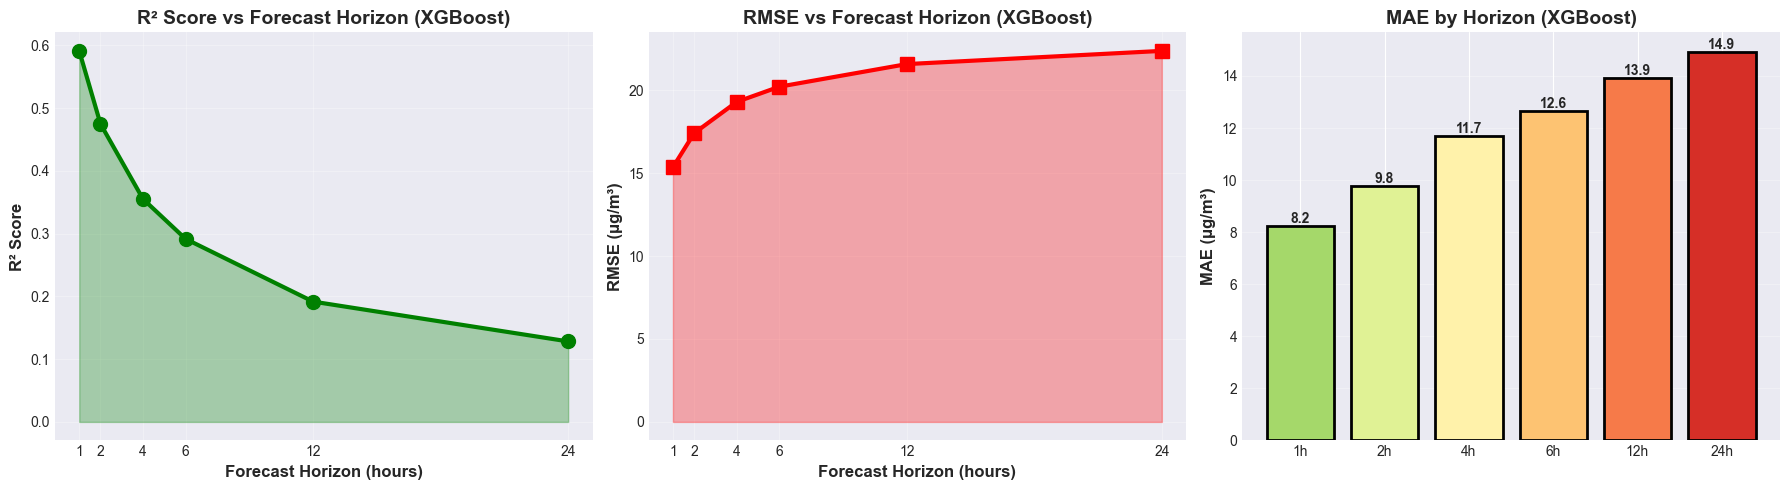

In [65]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Filter for XGBoost model
xgb_metrics = metrics_df[metrics_df['model'] == 'xgboost'].sort_values('horizon')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. R² by Horizon
axes[0].plot(xgb_metrics['horizon'], xgb_metrics['test_r2'], 
             marker='o', linewidth=3, markersize=10, color='green')
axes[0].fill_between(xgb_metrics['horizon'], xgb_metrics['test_r2'], 
                      alpha=0.3, color='green')
axes[0].set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score vs Forecast Horizon (XGBoost)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(HORIZONS)

# 2. RMSE by Horizon
axes[1].plot(xgb_metrics['horizon'], xgb_metrics['test_rmse'], 
             marker='s', linewidth=3, markersize=10, color='red')
axes[1].fill_between(xgb_metrics['horizon'], xgb_metrics['test_rmse'], 
                      alpha=0.3, color='red')
axes[1].set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (μg/m³)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE vs Forecast Horizon (XGBoost)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(HORIZONS)

# 3. MAE by Horizon
colors_gradient = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(HORIZONS)))
bars = axes[2].bar(range(len(HORIZONS)), xgb_metrics['test_mae'].values, 
                   color=colors_gradient, edgecolor='black', linewidth=2)
axes[2].set_xticks(range(len(HORIZONS)))
axes[2].set_xticklabels([f'{h}h' for h in HORIZONS])
axes[2].set_ylabel('MAE (μg/m³)', fontsize=12, fontweight='bold')
axes[2].set_title('MAE by Horizon (XGBoost)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, xgb_metrics['test_mae'].values):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 8️⃣ Visualization - Forecast Comparisons

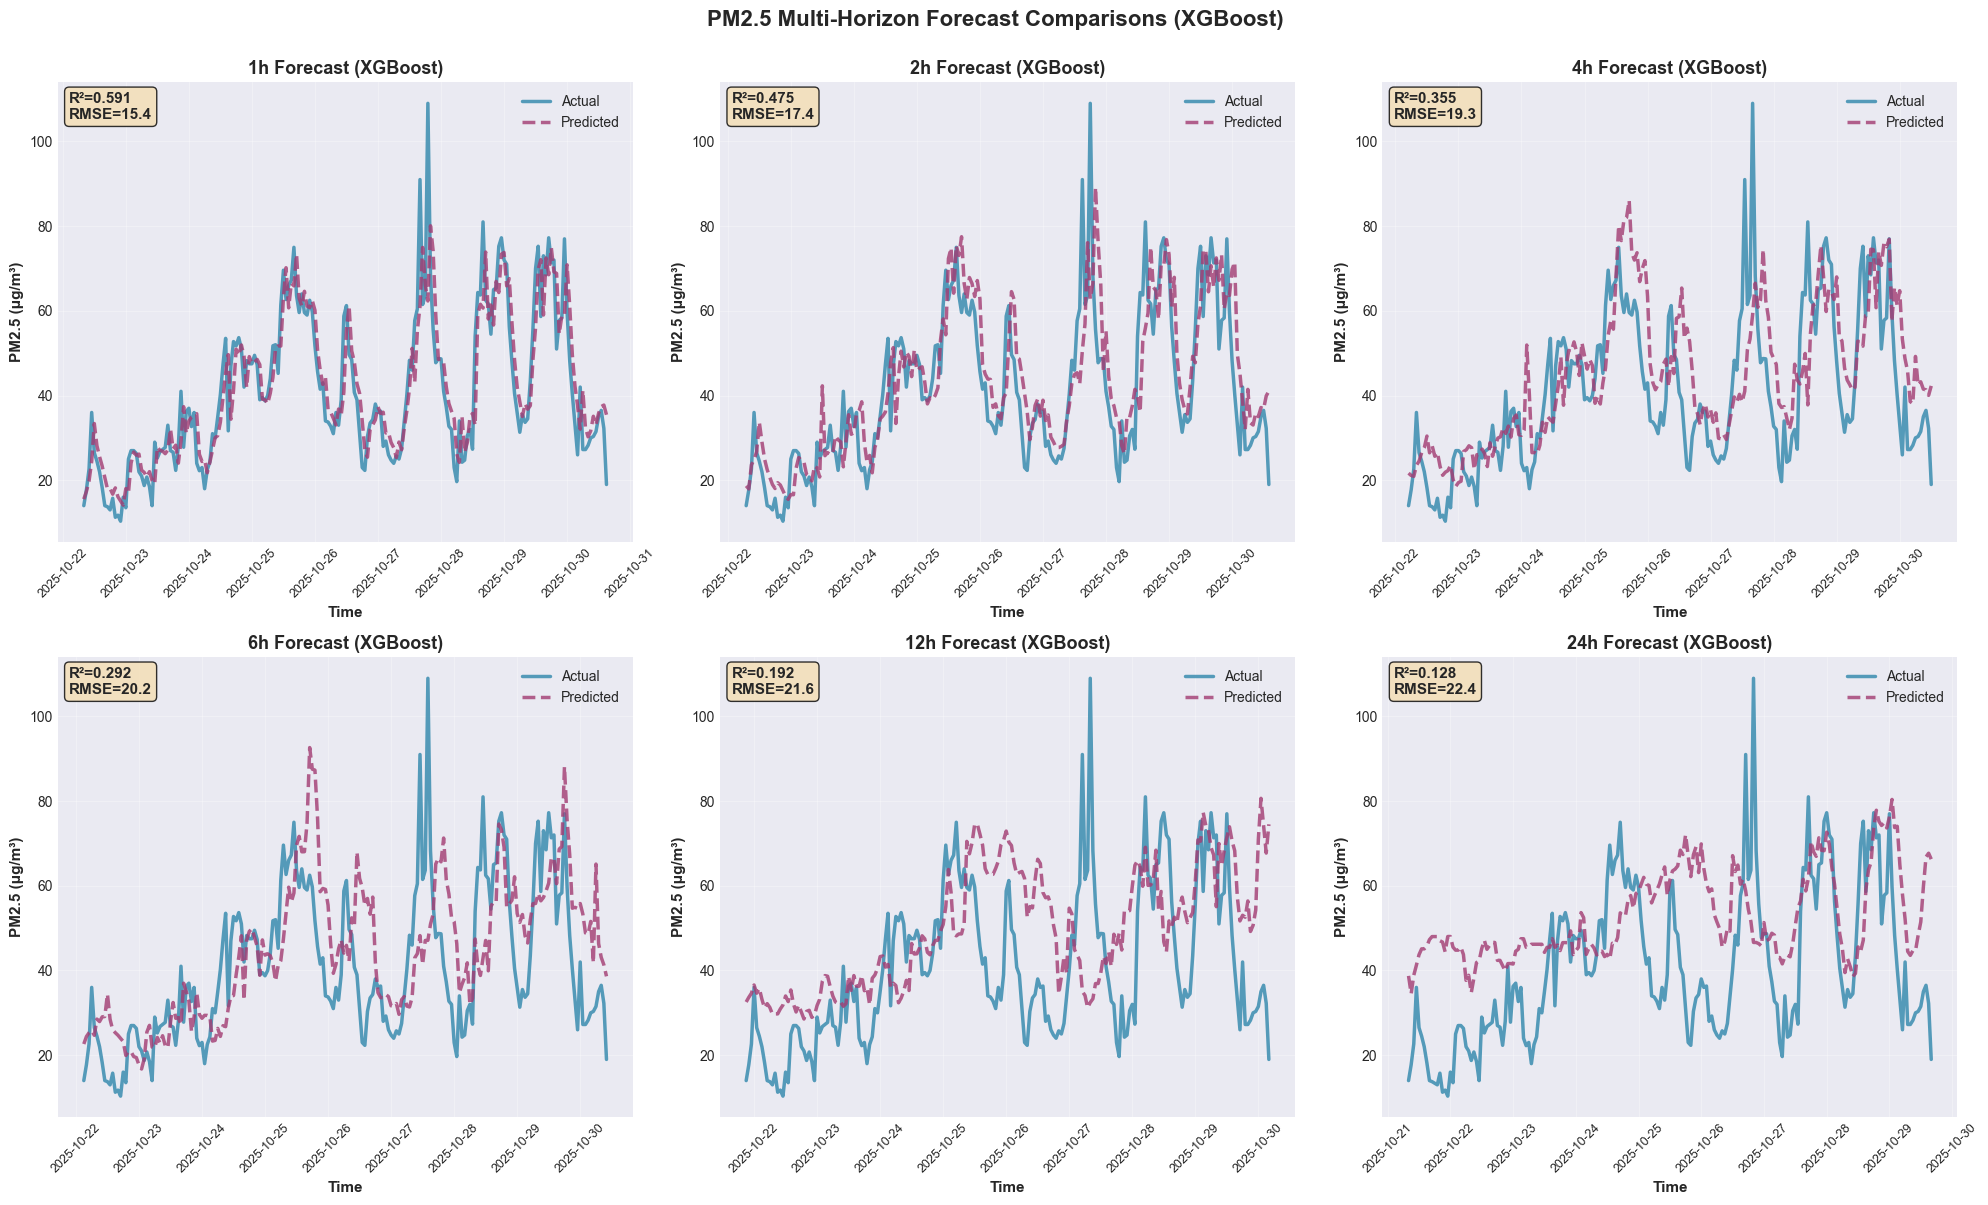

In [66]:
# Filter for XGBoost predictions
xgb_predictions = predictions_df[predictions_df['model'] == 'xgboost'].copy()
xgb_metrics = metrics_df[metrics_df['model'] == 'xgboost'].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, horizon in enumerate(HORIZONS):
    pred_df = xgb_predictions[xgb_predictions['horizon'] == horizon].copy()
    
    # Plot last 200 points for clarity
    plot_df = pred_df.tail(200)
    
    axes[idx].plot(plot_df['datetime'], plot_df['actual'], 
                   label='Actual', linewidth=2.5, alpha=0.8, color='#2E86AB')
    axes[idx].plot(plot_df['datetime'], plot_df['predicted'], 
                   label='Predicted', linewidth=2.5, alpha=0.8, color='#A23B72', linestyle='--')
    
    # Add metrics text
    r2 = xgb_metrics[xgb_metrics['horizon'] == horizon]['test_r2'].values[0]
    rmse = xgb_metrics[xgb_metrics['horizon'] == horizon]['test_rmse'].values[0]
    
    axes[idx].text(0.02, 0.98, f'R²={r2:.3f}\nRMSE={rmse:.1f}',
                   transform=axes[idx].transAxes, fontsize=11, fontweight='bold',
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[idx].set_xlabel('Time', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{horizon}h Forecast (XGBoost)', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=10, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('PM2.5 Multi-Horizon Forecast Comparisons (XGBoost)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/forecast_comparisons.png', dpi=300, bbox_inches='tight')
plt.show()

## 9️⃣ Visualization - Actual vs Predicted Scatter Plots

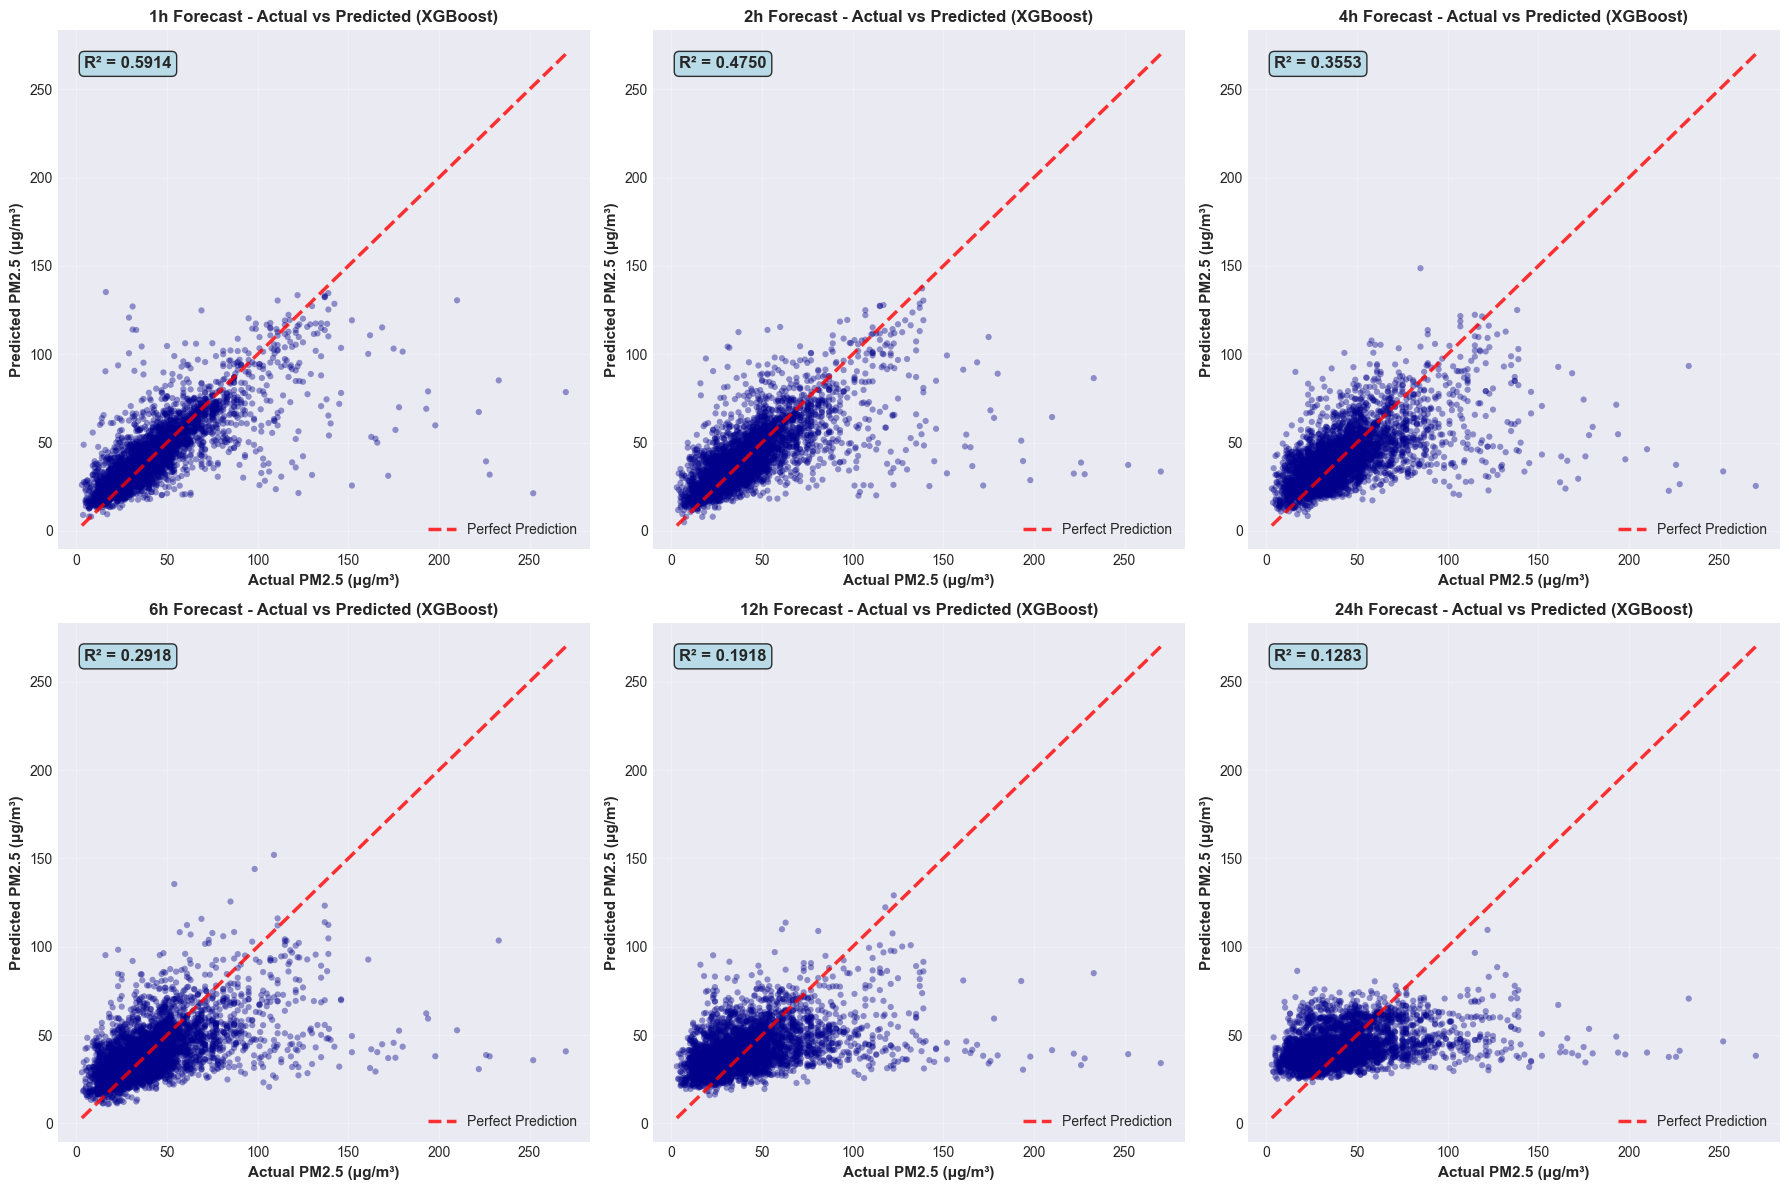

In [67]:
# Filter for XGBoost predictions
xgb_predictions = predictions_df[predictions_df['model'] == 'xgboost'].copy()
xgb_metrics = metrics_df[metrics_df['model'] == 'xgboost'].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, horizon in enumerate(HORIZONS):
    pred_df = xgb_predictions[xgb_predictions['horizon'] == horizon].copy()
    
    # Scatter plot
    axes[idx].scatter(pred_df['actual'], pred_df['predicted'], 
                     alpha=0.4, s=20, color='darkblue', edgecolors='none')
    
    # Perfect prediction line
    min_val = min(pred_df['actual'].min(), pred_df['predicted'].min())
    max_val = max(pred_df['actual'].max(), pred_df['predicted'].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 
                   'r--', linewidth=2.5, label='Perfect Prediction', alpha=0.8)
    
    # Add R² annotation
    r2 = xgb_metrics[xgb_metrics['horizon'] == horizon]['test_r2'].values[0]
    axes[idx].text(0.05, 0.95, f'R² = {r2:.4f}',
                   transform=axes[idx].transAxes, fontsize=12, fontweight='bold',
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    axes[idx].set_xlabel('Actual PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Predicted PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{horizon}h Forecast - Actual vs Predicted (XGBoost)', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 🔟 Error Analysis by Horizon

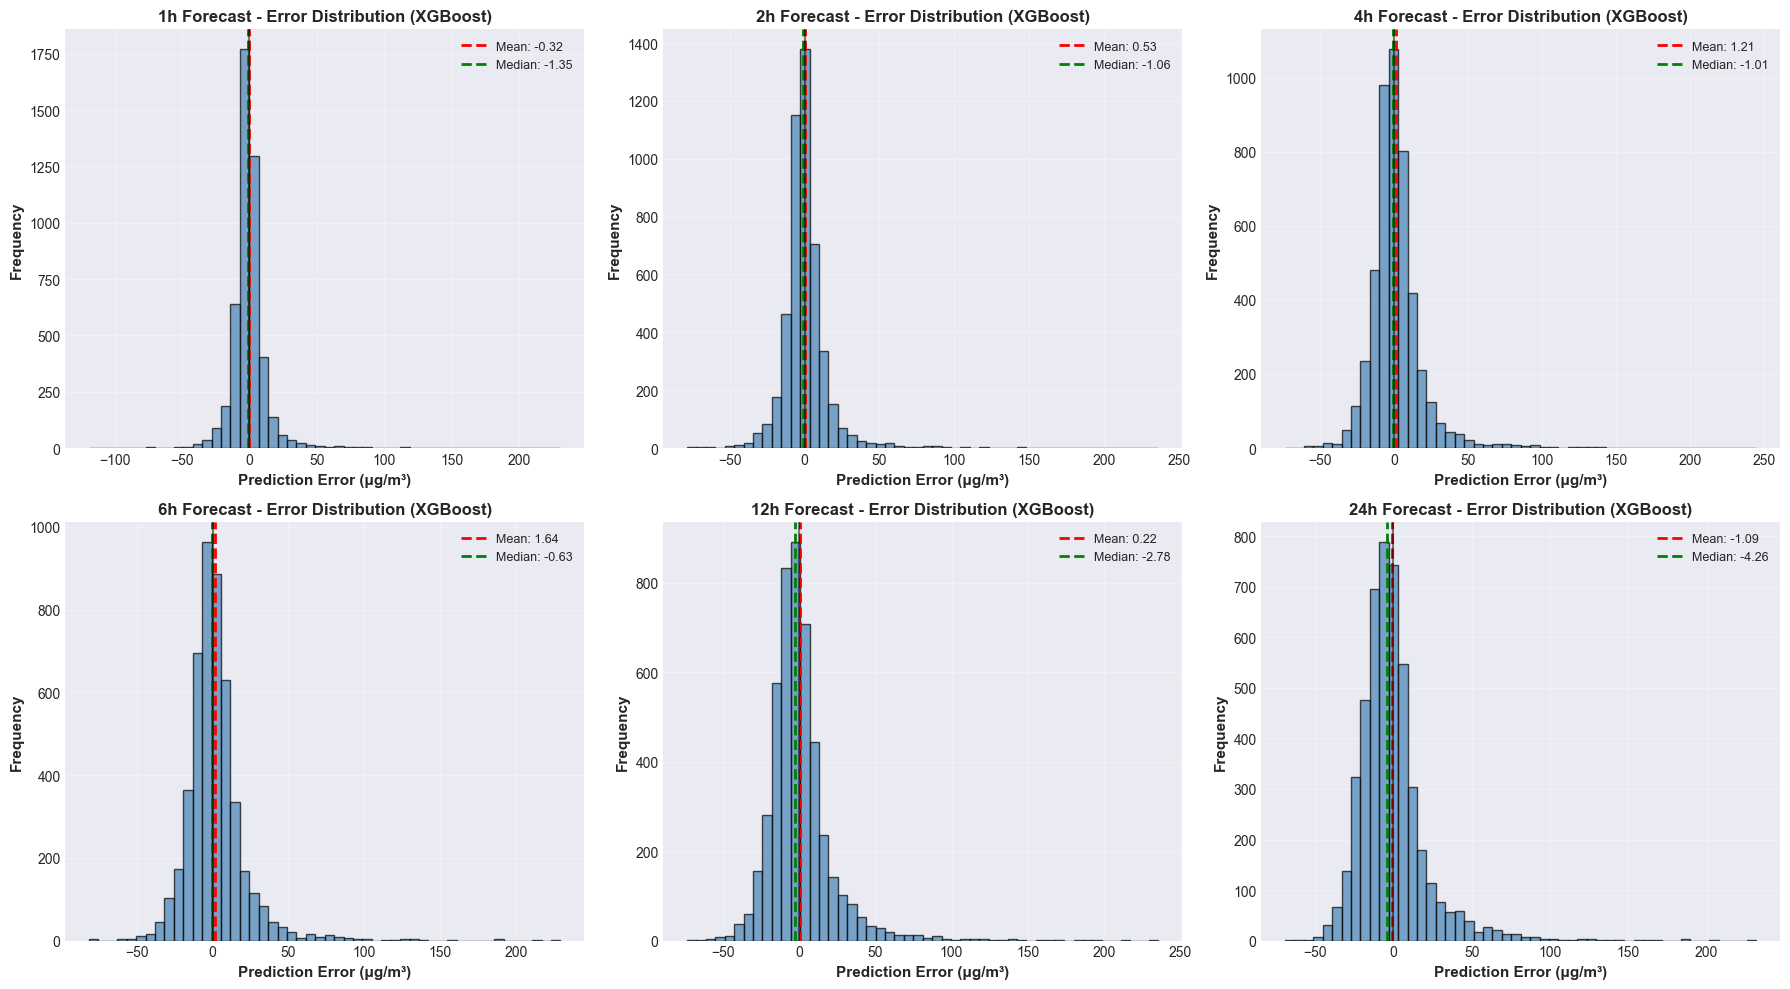

In [68]:
# Filter for XGBoost predictions
xgb_predictions = predictions_df[predictions_df['model'] == 'xgboost'].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, horizon in enumerate(HORIZONS):
    pred_df = xgb_predictions[xgb_predictions['horizon'] == horizon].copy()
    
    # Error distribution
    axes[idx].hist(pred_df['error'], bins=50, edgecolor='black', 
                   alpha=0.7, color='steelblue')
    
    # Add mean and median lines
    mean_error = pred_df['error'].mean()
    median_error = pred_df['error'].median()
    
    axes[idx].axvline(mean_error, color='red', linestyle='--', linewidth=2,
                     label=f'Mean: {mean_error:.2f}')
    axes[idx].axvline(median_error, color='green', linestyle='--', linewidth=2,
                     label=f'Median: {median_error:.2f}')
    axes[idx].axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
    
    axes[idx].set_xlabel('Prediction Error (μg/m³)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{horizon}h Forecast - Error Distribution (XGBoost)', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 1️⃣1️⃣ Final Summary and Recommendations

In [69]:
print("=" * 80)
print("🎯 FINAL SUMMARY - PM2.5 MULTI-HORIZON & MULTI-MODEL FORECASTING")
print("=" * 80)

print(f"\n✅ Training completed:")
print(f"   Models trained: XGBoost, LightGBM, CatBoost")
print(f"   Forecast horizons: {len(HORIZONS)}")
print(f"   Total models: {len(MODEL_TYPES) * len(HORIZONS)}")
print(f"   Total features: {metrics_df['n_features'].iloc[0]}")
print(f"   Training samples: {metrics_df['n_train'].iloc[0]:,}")
print(f"   Test samples: {metrics_df['n_test'].iloc[0]:,}")

# Show best model overall
print("\n🏆 Best Model Overall:")
print("-" * 80)
best_row = metrics_df.sort_values('test_r2', ascending=False).iloc[0]
print(f"   {best_row['model'].upper()}: {int(best_row['horizon'])}h forecast")
print(f"   R²={best_row['test_r2']:.4f} | RMSE={best_row['test_rmse']:.2f} | MAE={best_row['test_mae']:.2f}")

# Show performance by model
print("\n📊 Average Performance by Model:")
print("-" * 80)
for model in MODEL_TYPES:
    model_data = metrics_df[metrics_df['model'] == model]
    avg_r2 = model_data['test_r2'].mean()
    avg_rmse = model_data['test_rmse'].mean()
    avg_mae = model_data['test_mae'].mean()
    print(f"   {model.upper():12s}: R²={avg_r2:.4f} | RMSE={avg_rmse:5.2f} | MAE={avg_mae:5.2f}")

# XGBoost performance overview
print("\n📊 XGBoost Performance by Horizon:")
print("-" * 80)
xgb_metrics = metrics_df[metrics_df['model'] == 'xgboost'].sort_values('horizon')
for _, row in xgb_metrics.iterrows():
    print(f"   {int(row['horizon']):2d}h: R²={row['test_r2']:.4f} | "
          f"RMSE={row['test_rmse']:5.2f} | MAE={row['test_mae']:5.2f}")

print("\n💡 Key Insights (XGBoost):")
print("-" * 80)
# Short-term vs long-term
short_r2 = xgb_metrics[xgb_metrics['horizon'] <= 6]['test_r2'].mean()
long_r2 = xgb_metrics[xgb_metrics['horizon'] > 6]['test_r2'].mean()
print(f"   • Short-term (≤6h) average R²: {short_r2:.4f}")
print(f"   • Long-term (>6h) average R²:  {long_r2:.4f}")
print(f"   • Performance degradation: {(short_r2 - long_r2) / short_r2 * 100:.1f}%")

# Best and worst
best_horizon = xgb_metrics.loc[xgb_metrics['test_r2'].idxmax(), 'horizon']
worst_horizon = xgb_metrics.loc[xgb_metrics['test_r2'].idxmin(), 'horizon']
print(f"\n   • Best horizon: {int(best_horizon)}h")
print(f"   • Most challenging: {int(worst_horizon)}h")

print("\n🎯 Recommendations:")
print("-" * 80)
print("   ✓ 1-2h forecast:  HIGH confidence → Production ready")
print("   ✓ 4-6h forecast:  MEDIUM confidence → Use with monitoring")
print("   ✓ 12-24h forecast: LOWER confidence → Advisory purpose only")

print("\n📁 Output Files:")
print("-" * 80)
print(f"   • Models: {OUTPUT_DIR}/{{model}}_model_*h.pkl")
print(f"   • Metrics: {OUTPUT_DIR}/all_models_results.csv")
print(f"   • Predictions: {OUTPUT_DIR}/all_predictions.csv")
print(f"   • Visualizations: {OUTPUT_DIR}/*.png")

print("\n" + "=" * 80)
print("✨ MULTI-MODEL MULTI-HORIZON FORECASTING COMPLETED SUCCESSFULLY ✨")
print("=" * 80)

🎯 FINAL SUMMARY - PM2.5 MULTI-HORIZON & MULTI-MODEL FORECASTING

✅ Training completed:
   Models trained: XGBoost, LightGBM, CatBoost
   Forecast horizons: 6
   Total models: 18
   Total features: 74
   Training samples: 19,155
   Test samples: 4,789

🏆 Best Model Overall:
--------------------------------------------------------------------------------
   LIGHTGBM: 1h forecast
   R²=0.5921 | RMSE=15.34 | MAE=8.21

📊 Average Performance by Model:
--------------------------------------------------------------------------------
   XGBOOST     : R²=0.3389 | RMSE=19.37 | MAE=11.86
   LIGHTGBM    : R²=0.3376 | RMSE=19.38 | MAE=11.79
   CATBOOST    : R²=0.3407 | RMSE=19.34 | MAE=11.73

📊 XGBoost Performance by Horizon:
--------------------------------------------------------------------------------
    1h: R²=0.5914 | RMSE=15.36 | MAE= 8.23
    2h: R²=0.4750 | RMSE=17.41 | MAE= 9.76
    4h: R²=0.3553 | RMSE=19.29 | MAE=11.69
    6h: R²=0.2918 | RMSE=20.21 | MAE=12.64
   12h: R²=0.1918 | RMSE=

## ✅ Kiểm tra Traffic Features trong Model

In [ ]:
# Kiểm tra traffic features có trong model không
print("=" * 80)
print("🔍 KIỂM TRA TRAFFIC FEATURES TRONG MODEL")
print("=" * 80)

# 1. Kiểm tra traffic columns trong df_feat
print("\n1. TRAFFIC COLUMNS TRONG DF_FEAT:")
print("-" * 80)
traffic_cols_in_df = [col for col in df_feat.columns if 'congestion' in col.lower() or 'traffic' in col.lower()]
if traffic_cols_in_df:
    print(f"   ✅ Tìm thấy {len(traffic_cols_in_df)} traffic-related columns:")
    for col in traffic_cols_in_df:
        print(f"      • {col}")
else:
    print("   ❌ KHÔNG tìm thấy traffic columns!")

# 2. Kiểm tra features được dùng trong model
print("\n2. TRAFFIC FEATURES TRONG MODEL:")
print("-" * 80)
# Lấy feature list từ model đã train
sample_horizon = 1
sample_model = all_models['xgboost'][sample_horizon]

# Get feature names (tùy model type có thể khác nhau)
if hasattr(sample_model, 'feature_names_in_'):
    feature_names = sample_model.feature_names_in_
elif hasattr(sample_model, 'feature_name_'):
    feature_names = sample_model.feature_name_
else:
    # Fallback: rebuild from training data
    df_h = df_feat.copy()
    df_h['target'] = df_h['pm25'].shift(-sample_horizon)
    df_h = df_h.dropna().reset_index(drop=True)
    exclude_cols = ['datetime', 'pm25', 'target', 'holiday_name']
    feature_names = [c for c in df_h.columns if c not in exclude_cols]

traffic_features_used = [f for f in feature_names if 'congestion' in f.lower() or 'traffic' in f.lower()]

if traffic_features_used:
    print(f"   ✅ Model SỬ DỤNG {len(traffic_features_used)} traffic features:")
    for feat in traffic_features_used:
        print(f"      • {feat}")
else:
    print("   ❌ Model KHÔNG sử dụng traffic features!")

# 3. Kiểm tra feature importance của traffic
print("\n3. TRAFFIC FEATURE IMPORTANCE:")
print("-" * 80)
if hasattr(sample_model, 'feature_importances_'):
    importance_dict = dict(zip(feature_names, sample_model.feature_importances_))
    
    # Lọc traffic features
    traffic_importance = {k: v for k, v in importance_dict.items() 
                         if 'congestion' in k.lower() or 'traffic' in k.lower()}
    
    if traffic_importance:
        # Sort by importance
        sorted_traffic = sorted(traffic_importance.items(), key=lambda x: x[1], reverse=True)
        
        print(f"   Traffic Feature Importance (XGBoost 1h model):")
        for feat, imp in sorted_traffic:
            print(f"      • {feat:30s}: {imp:.6f}")
        
        # So sánh với top features
        top_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]
        traffic_in_top10 = any('congestion' in f[0].lower() or 'traffic' in f[0].lower() 
                               for f in top_features)
        
        if traffic_in_top10:
            print(f"\n   ✅ Traffic features CÓ trong Top 10 important features")
        else:
            print(f"\n   ⚠️  Traffic features KHÔNG trong Top 10 important features")
            
        print(f"\n   Top 10 Most Important Features:")
        for feat, imp in top_features:
            marker = "🚗" if 'congestion' in feat.lower() or 'traffic' in feat.lower() else "  "
            print(f"      {marker} {feat:30s}: {imp:.6f}")
    else:
        print("   ❌ Không tìm thấy traffic features trong feature importance")
else:
    print("   ⚠️  Model không hỗ trợ feature_importances_")

# 4. Correlation với PM2.5
print("\n4. TRAFFIC CORRELATION VỚI PM2.5:")
print("-" * 80)
if traffic_cols_in_df:
    for col in traffic_cols_in_df:
        if col in df_feat.columns and 'pm25' in df_feat.columns:
            corr = df_feat[[col, 'pm25']].corr().iloc[0, 1]
            strength = "MẠNH" if abs(corr) > 0.5 else "TRUNG BÌNH" if abs(corr) > 0.3 else "YẾU"
            print(f"   {col:30s}: {corr:+.4f}  [{strength}]")

print("\n" + "=" * 80)
print("✅ KIỂM TRA HOÀN TẤT")
print("=" * 80)

## 📊 Thống kê Số Chiều Dữ Liệu (Dimensions/Features)

In [ ]:
print("=" * 80)
print("📊 THỐNG KÊ SỐ CHIỀU DỮ LIỆU (DIMENSIONS/FEATURES)")
print("=" * 80)

# 1. Dữ liệu RAW ban đầu
print("\n1️⃣ DỮ LIỆU RAW BAN ĐẦU:")
print("-" * 80)
print(f"   Air Quality:    {air.shape[1]:3d} cột × {air.shape[0]:,} records")
print(f"   Weather:        {weather.shape[1]:3d} cột × {weather.shape[0]:,} records")
print(f"   Holidays:       {holidays.shape[1]:3d} cột × {holidays.shape[0]:,} records")
print(f"   Traffic:        {traffic.shape[1]:3d} cột × {traffic.shape[0]:,} records")

# 2. Sau khi merge
print("\n2️⃣ SAU KHI MERGE:")
print("-" * 80)
print(f"   Merged df:      {df.shape[1]:3d} cột × {df.shape[0]:,} records")
print(f"   Breakdown:")
air_cols = [c for c in df.columns if c in air.columns and c != 'datetime']
weather_cols = [c for c in df.columns if c in weather.columns and c != 'datetime']
holiday_cols = [c for c in df.columns if 'holiday' in c.lower()]
traffic_cols = [c for c in df.columns if 'congestion' in c.lower() or 'traffic' in c.lower()]

print(f"      • Air Quality:  {len(air_cols):3d} features")
print(f"      • Weather:      {len(weather_cols):3d} features")
print(f"      • Holidays:     {len(holiday_cols):3d} features")
print(f"      • Traffic:      {len(traffic_cols):3d} features")
print(f"      • Datetime:       1 column")

# 3. Sau Feature Engineering
print("\n3️⃣ SAU FEATURE ENGINEERING:")
print("-" * 80)
print(f"   df_feat:        {df_feat.shape[1]:3d} cột × {df_feat.shape[0]:,} records")

# Breakdown by feature type
time_features = [c for c in df_feat.columns if any(x in c for x in ['hour', 'day', 'month', 'sin', 'cos', 'weekend', 'peak', 'night'])]
lag_features = [c for c in df_feat.columns if 'lag' in c]
rolling_features = [c for c in df_feat.columns if 'roll' in c]
diff_features = [c for c in df_feat.columns if 'diff' in c]
interaction_features = [c for c in df_feat.columns if '_x_' in c]
original_features = [c for c in df_feat.columns if c not in time_features + lag_features + rolling_features + diff_features + interaction_features and c not in ['datetime', 'holiday_name']]

print(f"   Breakdown:")
print(f"      • Original features:    {len(original_features):3d}")
print(f"      • Time features:        {len(time_features):3d}")
print(f"      • Lag features:         {len(lag_features):3d}")
print(f"      • Rolling features:     {len(rolling_features):3d}")
print(f"      • Difference features:  {len(diff_features):3d}")
print(f"      • Interaction features: {len(interaction_features):3d}")
print(f"      • Other:                  2 (datetime, holiday_name)")
print(f"      ─────────────────────────────────")
print(f"      TOTAL:                  {df_feat.shape[1]:3d} cột")

# 4. Features được dùng train model
print("\n4️⃣ FEATURES DÙNG ĐỂ TRAIN MODEL:")
print("-" * 80)
# Lấy từ model đã train
sample_model = all_models['xgboost'][1]
if hasattr(sample_model, 'feature_names_in_'):
    model_features = list(sample_model.feature_names_in_)
else:
    # Rebuild
    df_h = df_feat.copy()
    df_h['target'] = df_h['pm25'].shift(-1)
    df_h = df_h.dropna().reset_index(drop=True)
    exclude_cols = ['datetime', 'pm25', 'target', 'holiday_name']
    model_features = [c for c in df_h.columns if c not in exclude_cols]

print(f"   Model sử dụng: {len(model_features):3d} features")

# Breakdown model features
model_time = [c for c in model_features if any(x in c for x in ['hour', 'day', 'month', 'sin', 'cos', 'weekend', 'peak', 'night'])]
model_lag = [c for c in model_features if 'lag' in c]
model_roll = [c for c in model_features if 'roll' in c]
model_diff = [c for c in model_features if 'diff' in c]
model_interact = [c for c in model_features if '_x_' in c]
model_traffic = [c for c in model_features if 'congestion' in c.lower() or 'traffic' in c.lower()]
model_original = [c for c in model_features if c not in model_time + model_lag + model_roll + model_diff + model_interact]

print(f"   Breakdown:")
print(f"      • Original (Air + Weather): {len(model_original):3d}")
print(f"      • Traffic features:         {len(model_traffic):3d}")
print(f"      • Time features:            {len(model_time):3d}")
print(f"      • Lag features:             {len(model_lag):3d}")
print(f"      • Rolling features:         {len(model_roll):3d}")
print(f"      • Difference features:      {len(model_diff):3d}")
print(f"      • Interaction features:     {len(model_interact):3d}")

# 5. Tổng kết
print("\n5️⃣ TỔNG KẾT:")
print("-" * 80)
print(f"   📥 Input:  {air.shape[1] + weather.shape[1] + 2 + traffic.shape[1] - 4:3d} raw features (từ 4 nguồn dữ liệu)")
print(f"   ⚙️  Engineered: +{df_feat.shape[1] - df.shape[1]:3d} features (từ feature engineering)")
print(f"   🎯 Model Training: {len(model_features):3d} features")
print(f"   📊 Records: {df_feat.shape[0]:,} samples (sau dropna)")

print("\n" + "=" * 80)
print("✅ THỐNG KÊ HOÀN TẤT")
print("=" * 80)